<a href="https://colab.research.google.com/github/Ramsi-git/Assignment-on-Supervised-Learning-/blob/main/assignment_on_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI-Driven Employee Attrition Prediction

##1.Problem Overview

Employee attrition refers to employees leaving an organization voluntarily or involuntarily. High attrition negatively affects organizational performance and increases operational costs.The company wants to use Machine Learning to predict employees who arelikely to leave so HR teams can take preventive action.

###Why Employee Retention is Important

Employee retention is critical because experienced employees:
•Improve productivity
•Maintain project continuity
•Reduce training time
•Preserve organizational knowledge
•Support team morale
•Frequent resignations can damage both financial performance and company culture.

###Business Impact of Attrition

*Financial Impact
•Recruitment costs
•Training expenses
•Onboarding costs
*Operational Impact
•Delayed projects
•Knowledge loss
•Increased workload for remaining employees
*Cultural Impact
•Reduced employee morale
•Increased stress
•Lower engagement

##2.Data Exploration

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/IIT Palakkad Advanced AI/Dataset/employee_attrition_dataset.csv')

In [ ]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


Attrition (Target Variable)
Yes → Employee left the organization
No → Employee stayed in the organization

In [ ]:
#checking missing values
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


No missing values.

In [ ]:
#Data type analysis
df.dtypes

,0
Employee_ID,int64
Age,int64
Gender,object
Marital_Status,object
Department,object
Job_Role,object
Job_Level,int64
Monthly_Income,int64
Hourly_Rate,int64
Years_at_Company,int64


In [ ]:
#Duplicate checking
df.duplicated().sum()

np.int64(0)

In [ ]:
#Statistics
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


##3.Exploratory Data Analysis(EDA)

<Axes: xlabel='Attrition', ylabel='count'>

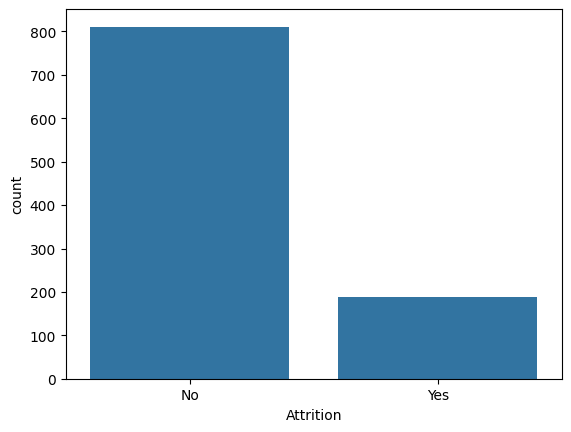

In [ ]:
#Attrition distribution
sns.countplot(x='Attrition', data=df)

<Axes: xlabel='Department', ylabel='count'>

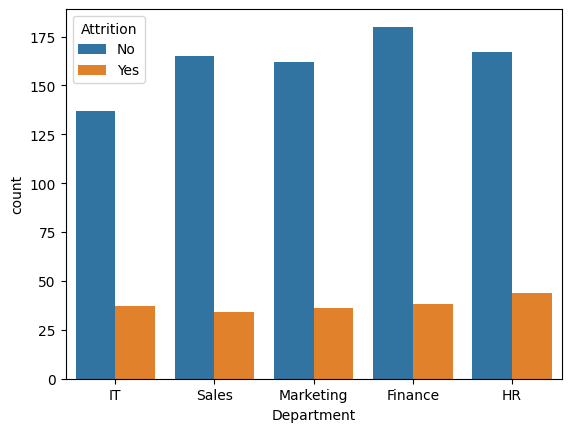

In [ ]:
#Attrition by department
sns.countplot(x='Department', hue='Attrition', data=df)

<Axes: xlabel='Overtime', ylabel='count'>

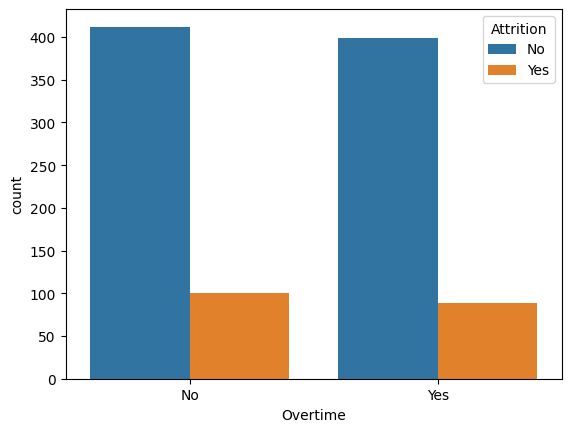

In [ ]:
#Attrition by overtime
sns.countplot(x='Overtime', hue='Attrition', data=df)

<Axes: xlabel='Attrition', ylabel='Monthly_Income'>

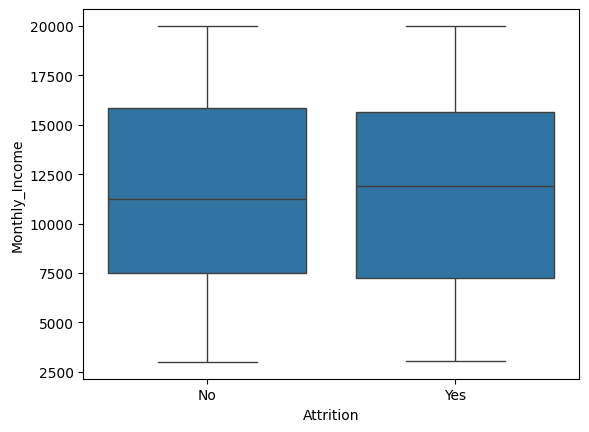

In [ ]:
#Attrition by salary
sns.boxplot(x='Attrition', y='Monthly_Income', data=df)

<Axes: xlabel='Job_Satisfaction', ylabel='count'>

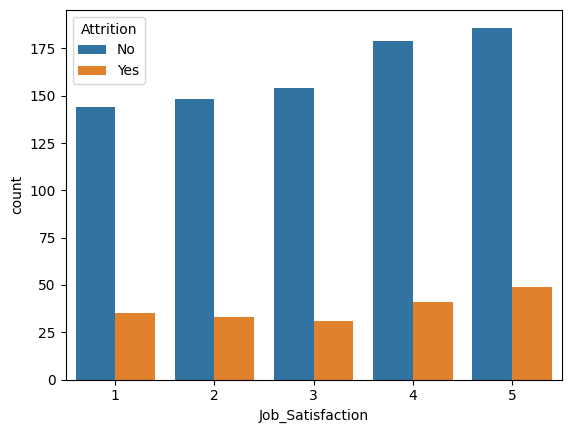

In [ ]:
#Attrition by job satisfaction
sns.countplot(x='Job_Satisfaction', hue='Attrition', data=df)

numerical_features = [
    'Employee_ID',
    'Age',
    'Job_Level',
    'Monthly_Income',
    'Hourly_Rate',
    'Years_at_Company',
    'Years_in_Current_Role',
    'Years_Since_Last_Promotion',
    'Work_Life_Balance',
    'Job_Satisfaction',
    'Performance_Rating',
    'Training_Hours_Last_Year',
    'Project_Count',
    'Average_Hours_Worked_Per_Week',
    'Absenteeism',
    'Work_Environment_Satisfaction',
    'Relationship_with_Manager',
    'Job_Involvement',
    'Distance_From_Home',
    'Number_of_Companies_Worked'
]

In [ ]:
num_cols=df.select_dtypes(include=np.number)

In [ ]:
num_cols

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
0,1,58,1,15488,28,15,4,2,1,3,4,14,6,54,17,4,4,4,20,3
1,2,48,5,13079,28,6,9,1,2,1,1,6,2,45,1,4,1,2,25,2
2,3,34,1,13744,24,24,14,8,3,2,1,77,6,34,2,3,4,4,45,3
3,4,27,1,6809,26,10,8,2,3,5,4,49,9,48,18,2,3,1,35,3
4,5,40,1,10206,52,29,10,1,2,5,1,64,3,33,0,4,1,3,44,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,27,2,4172,76,24,14,3,4,5,4,76,4,46,10,3,1,4,24,4
996,997,47,4,11007,71,19,6,0,3,1,1,53,7,36,16,3,2,4,39,3
997,998,50,1,4641,43,25,12,3,4,1,1,7,1,46,9,2,3,3,33,2
998,999,28,4,19855,92,13,13,0,2,2,2,54,4,52,17,4,1,4,41,4


<Axes: >

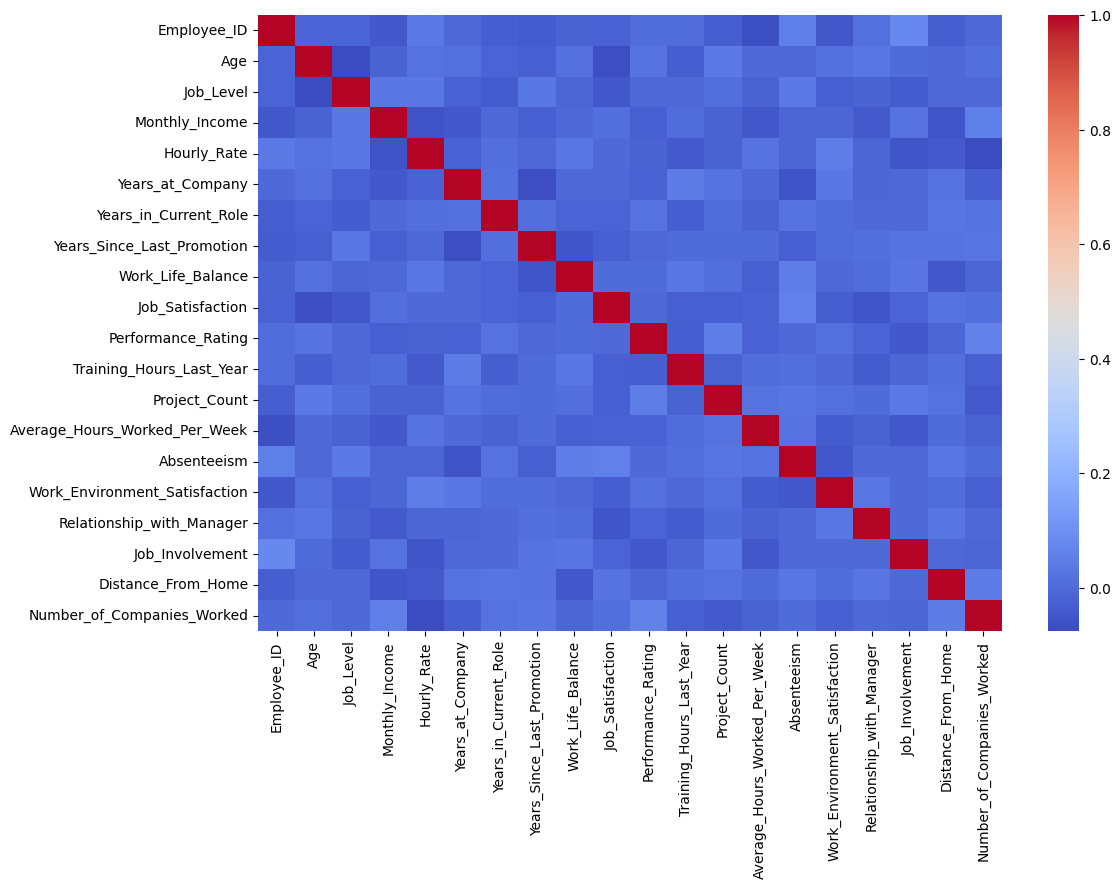

In [ ]:
#Correlation Heatmap
corr=num_cols.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')

##4.Data Preprocessing

Handling missing values:There is no missing values in this dataset

categorical_features = [
    'Gender',
    'Marital_Status',
    'Department',
    'Job_Role',
    'Overtime',
    'Attrition'
]

In [ ]:
#Encoding Categorical values
cat_cols = df.select_dtypes(include='object')

In [ ]:
cat_cols

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
0,Female,Married,IT,Manager,No,No
1,Female,Married,Sales,Assistant,Yes,No
2,Male,Married,Marketing,Assistant,Yes,No
3,Female,Divorced,Marketing,Manager,No,No
4,Male,Divorced,Marketing,Executive,No,No
...,...,...,...,...,...,...
995,Female,Divorced,HR,Analyst,No,No
996,Male,Single,IT,Manager,Yes,Yes
997,Female,Divorced,IT,Executive,Yes,No
998,Female,Married,HR,Executive,No,No


In [ ]:
#Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
     df[col]=le.fit_transform(df[col])

In [ ]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,0,1,2,3,1,15488,28,15,...,0,6,54,17,4,4,4,20,3,0
1,2,48,0,1,4,1,5,13079,28,6,...,1,2,45,1,4,1,2,25,2,0
2,3,34,1,1,3,1,1,13744,24,24,...,1,6,34,2,3,4,4,45,3,0
3,4,27,0,0,3,3,1,6809,26,10,...,0,9,48,18,2,3,1,35,3,0
4,5,40,1,0,3,2,1,10206,52,29,...,0,3,33,0,4,1,3,44,3,0


In [ ]:
#Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled= scaler.fit_transform(df[num_cols.columns])

In [ ]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,0,1,2,3,1,15488,28,15,...,0,6,54,17,4,4,4,20,3,0
1,2,48,0,1,4,1,5,13079,28,6,...,1,2,45,1,4,1,2,25,2,0
2,3,34,1,1,3,1,1,13744,24,24,...,1,6,34,2,3,4,4,45,3,0
3,4,27,0,0,3,3,1,6809,26,10,...,0,9,48,18,2,3,1,35,3,0
4,5,40,1,0,3,2,1,10206,52,29,...,0,3,33,0,4,1,3,44,3,0


In [ ]:
#Train-Test Split
X=df.drop('Attrition',axis=1)
y=df['Attrition']

In [ ]:
X.head(2)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
0,1,58,0,1,2,3,1,15488,28,15,...,14,0,6,54,17,4,4,4,20,3
1,2,48,0,1,4,1,5,13079,28,6,...,6,1,2,45,1,4,1,2,25,2


In [ ]:
y.head(2)

,Attrition
0,0
1,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [ ]:
X_train.head(2)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
29,30,34,0,1,0,2,2,16667,25,25,...,89,1,1,48,1,4,4,4,29,4
535,536,57,1,1,2,2,4,18187,64,4,...,91,1,5,39,4,4,1,4,18,2


In [ ]:
X_test.head(2)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
521,522,31,0,1,0,3,2,10601,36,9,...,31,1,2,34,10,2,1,4,34,1
737,738,41,0,0,4,0,3,3240,42,23,...,86,1,7,51,12,4,1,3,20,4


In [ ]:
y_train.head(2)

,Attrition
29,0
535,0


In [ ]:
y_test.head(2)

,Attrition
521,0
737,0


##5.ML Model Building

In [ ]:
#1.Logistic Regression
from sklearn.linear_model import LogisticRegression
#initialize model
log_model=LogisticRegression()
#train model
log_model.fit(X_train,y_train)
#make predictions using the model
y_pred_log=log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#2.Decision tree
from sklearn.tree import DecisionTreeClassifier
#initialize model
DT_model=DecisionTreeClassifier()
#train model
DT_model.fit(X_train,y_train)
#make predictions using the model
y_pred_DT=DT_model.predict(X_test)

In [ ]:
#3.Random forest
from sklearn.ensemble import RandomForestClassifier
#initialize model
rf_model= RandomForestClassifier()
#train model
rf_model.fit(X_train, y_train)
#make predictions using the model
y_pred_rf=rf_model.predict(X_test)

##6.Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

Logistic Regression

In [ ]:
acc=accuracy_score(y_test, y_pred_log)
prec=precision_score(y_test, y_pred_log,average='weighted')
recall=recall_score(y_test, y_pred_log,average='weighted')
f1=f1_score(y_test, y_pred_log,average='weighted')
conf_matrix=confusion_matrix(y_test, y_pred_log)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print('Accuracy of the model:',acc)
print('Precision of the model:',prec)
print('Recall of the model:',recall)
print('F1 score of the model:',f1)
print('Confusion matrix of the model:',conf_matrix)

Accuracy of the model: 0.845
Precision of the model: 0.714025
Recall of the model: 0.845
F1 score of the model: 0.774010840108401
Confusion matrix of the model: [[169   0]
 [ 31   0]]


Decision Tree

In [ ]:
acc_DT=accuracy_score(y_test, y_pred_DT)
prec_DT=precision_score(y_test, y_pred_DT,average='weighted')
recall_DT=recall_score(y_test, y_pred_DT,average='weighted')
f1_DT=f1_score(y_test, y_pred_DT,average='weighted')
conf_matrix_DT=confusion_matrix(y_test, y_pred_DT)
print('Accuracy of the model:',acc_DT)
print('Precision of the model:',prec_DT)
print('Recall of the model:',recall_DT)
print('F1 score of the model:',f1_DT)
print('Confusion matrix of the model:',conf_matrix_DT)

Accuracy of the model: 0.7
Precision of the model: 0.7650085537570733
Recall of the model: 0.7
F1 score of the model: 0.7271514035895076
Confusion matrix of the model: [[129  40]
 [ 20  11]]


Random Forest

In [ ]:
acc_rf=accuracy_score(y_test, y_pred_rf)
prec_rf=precision_score(y_test, y_pred_rf,average='weighted')
recall_rf=recall_score(y_test, y_pred_rf,average='weighted')
f1_rf=f1_score(y_test, y_pred_rf,average='weighted')
conf_matrix_rf=confusion_matrix(y_test, y_pred_rf)
print('Accuracy of the model:',acc_rf)
print('Precision of the model:',prec_rf)
print('Recall of the model:',recall_rf)
print('F1 score of the model:',f1_rf)
print('Confusion matrix of the model:',conf_matrix_rf)

Accuracy of the model: 0.845
Precision of the model: 0.714025
Recall of the model: 0.845
F1 score of the model: 0.774010840108401
Confusion matrix of the model: [[169   0]
 [ 31   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


?:Which model performs best

Model 1.Logistic Regression       
Accuracy   84.5%
Precision  71.40%
Recall     84.5%
F1-Score   77.40%

Model 2.Decision Tree
Accuracy   70%
Precision  76.50%
Recall     70%
F1-Score   72.71%

Model 3.Random Forest
Accuracy   84.5%
Precision  71.40%
Recall     84.5%
F1-Score   77.40%

Both Logistic Regression and
Random Forest models are  predicted almost all employees as:
"No Attrition"
i.e.,
•They achieved high accuracy because most employees stayed.
•But they failed to identify employees who actually left.

The Decision Tree model correctly identified some employees likely to leave.Although its overall accuracy is lower, it provides better business usefulness.

###Decision Tree is the most practically useful model.

Reason:
In attrition prediction:
•Identifying employees at risk
is more important than just
achieving high accuracy.
Decision Tree:
•Detected actual attrition cases
•Helps HR take preventive action
•Provides interpretable decision rules

Why certain metrics are important in business scenarios:

In business scenarios, evaluation metrics help organizations understand how effectively a machine learning model makes predictions and supports decision making.Accuracy measures overall correctness, precision shows how many predicted attrition cases are actually correct, recall identifies how many employees likely to leave are successfully detected, and F1score balances both precision and recall. In employee attrition prediction, recall is especially important because failingto identify employees who may resign can lead to increased recruitment costs, productivity loss,project delays, and reduced employee morale. These metrics help businesses choose models that not only perform well technically but also provide practical valuefor strategic HR planning and employee retention.

##7.Business Insights and Recommendations

Key Factors Influencing
Attrition

Based on EDA and feature analysis,important factors affecting attrition include:
•Overtime
•Low monthly income
•Poor work-life balance
•Low job satisfaction
•Lack of promotions
•High working hours
•Poor relationship with managers
•High absenteeism

High-Risk Employee Profiles

Employees with the following characteristics are more likely to leave:
................................
Risk Indicator ==> Descriptions
................................
•Frequent overtime ==> Increased work stress
•Low salary ==> Reduced employee satisfaction
•Low job satisfaction ==> Higher resignation probability
•Poor work life balance ==> Employee burnout
•No recent Promotions ==> Lack of career growth
•Long working hours ==> Fatigue and stress
•Poor manager relationships ==> Lower engagement
................................

Departments with Higher Attrition Risk:

•Sales
•Customer support
•Technical operations
These departments require additional HR focus and retention programs.

HR Intervention Strategies

1.Reduce Overtime
2.Improve Employee Satisfaction
3.Enhance Career Growth Opportunities
4.Improve Compensation and Benefits
5.Strengthen Manager-Employee Relationships
6.Improve Work-Life Balance

Actionable recommendations for management.

1.Implement AI-based attrition monitoring
systems to identify
high-risk employees early.
2.Reduce overtime and excessive workload to prevent employee
burnout.
3.Improve employee satisfaction through recognition and engagement programs.
4.Provide career growth opportunities, promotions, and skill development training.
5.Offer competitive salaries andretention benefits to improve employee loyalty.
6.Strengthen manager-employee relationships through effective communication and leadership training.
7.Promote work-life balance using flexible workoptions and wellness programs.